In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Indian_Kids_Screen_Time1.csv")
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [3]:
df.head(5)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
df.tail(5)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   str    
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   str    
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   str    
 7   Urban_or_Rural                     9712 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 540.7 KB


In [6]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [7]:
df.shape

(9712, 8)

In [8]:
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='str')

In [9]:
df = df.dropna()
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [10]:
df.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

In [11]:
df["Age_Band"] = pd.cut(df["Age"],bins=[0, 9, 13, 18],labels=["0–9", "10–13", "14–18"])
df["Age_Band"]

0       14–18
1       10–13
2       14–18
4       10–13
5       14–18
        ...  
9707    14–18
9708    14–18
9709    14–18
9710    14–18
9711    14–18
Name: Age_Band, Length: 6494, dtype: category
Categories (3, str): ['0–9' < '10–13' < '14–18']

In [12]:
df["Screen_Time_Level"] = pd.cut(df["Avg_Daily_Screen_Time_hr"],bins=[0, 2, 4, 6, 24],labels=["Low", "Moderate", "High", "Very High"])
df["Screen_Time_Level"]

0        Moderate
1            High
2        Moderate
4            High
5            High
          ...    
9707     Moderate
9708         High
9709         High
9710         High
9711    Very High
Name: Screen_Time_Level, Length: 6494, dtype: category
Categories (4, str): ['Low' < 'Moderate' < 'High' < 'Very High']

In [13]:
df["Primary_Device"].unique()
df["Primary_Device"] = df["Primary_Device"].str.strip()
df["Primary_Device"].value_counts()

Primary_Device
Smartphone    3098
TV            1583
Laptop        1053
Tablet         760
Name: count, dtype: int64

1. Univariate Graphs

Age Distribution

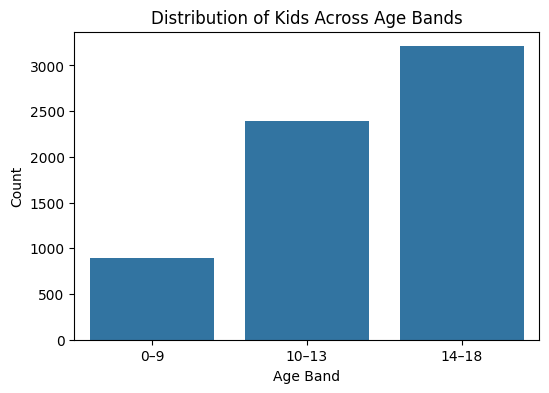

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Age_Band")
plt.title("Distribution of Kids Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

The majority of children falls in the 14-18 and 10-13 age groups, where 14-18 group having the highest representation and 0-9 age group has comparatively fewer participants that shows the dataset is more focused on older children.

Primary Device Distribution

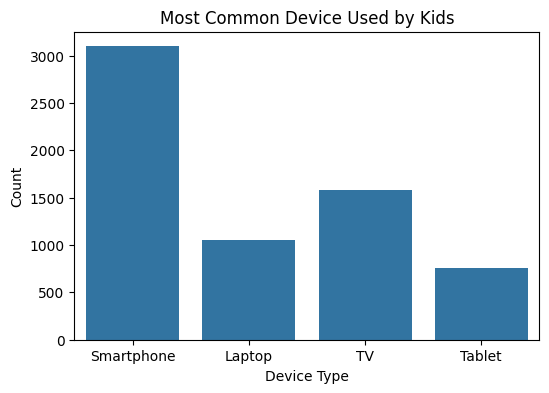

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Primary_Device")
plt.title("Most Common Device Used by Kids")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

Smartphones are the most commonly used devices among children, followed by TVs. Laptops and tablets are comparatively less used

Gender Distribution

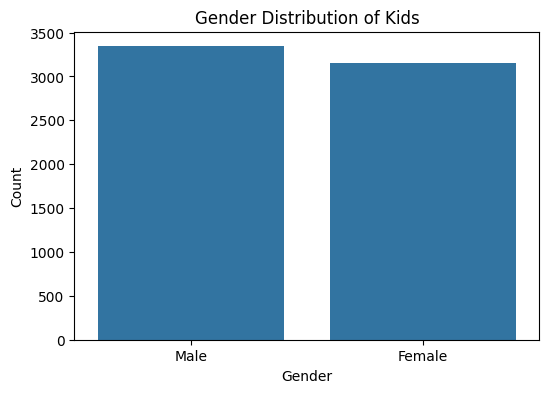

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution of Kids")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Male participants are slightly higher than female participants in the dataset

Screen Time Distribution

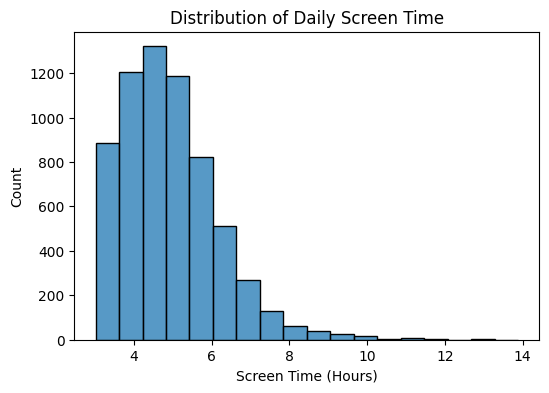

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["Avg_Daily_Screen_Time_hr"], bins=18)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Count")
plt.show()

A large proportion of children fall into the high, moderate and very high screen time categories, suggesting widespread excessive screen exposure among the population.

2. Bivariate Graphs

Age Band vs Screen Time

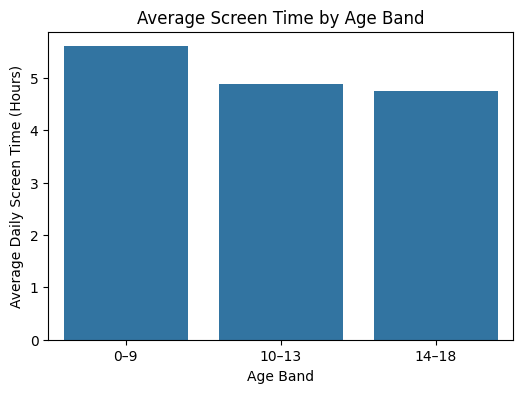

In [18]:
age_band_avg = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=age_band_avg,x="Age_Band",y="Avg_Daily_Screen_Time_hr")
plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

The 6–9 age group shows the highest average screen time, which is unexpected. This may be driven by higher usage of devices such as TVs and tablets among younger children.

Device Based Analysis by Screen Time


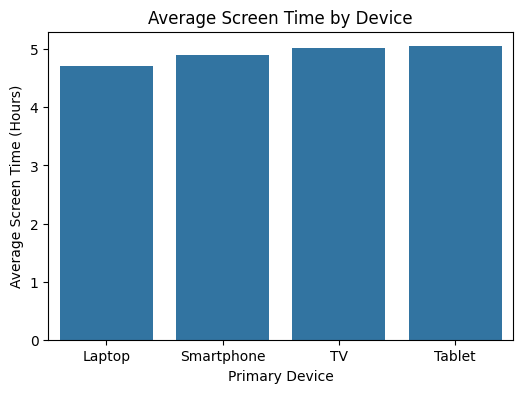

In [19]:
device_avg = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(
    data=device_avg,
    x="Primary_Device",
    y="Avg_Daily_Screen_Time_hr"
)
plt.title("Average Screen Time by Device")
plt.xlabel("Primary Device")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

Tablet users show the highest average daily screen time, followed by TV users. Smartphone and laptop users have comparatively lower screen exposure.

Gender vs Screen Time

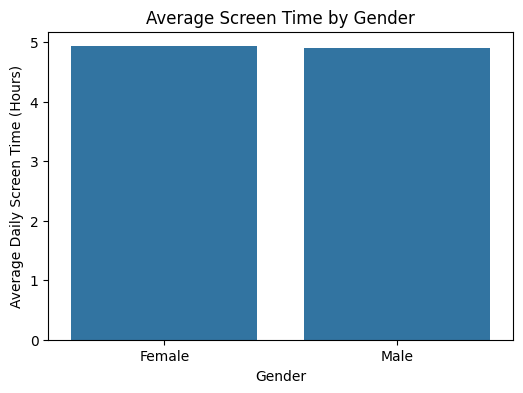

In [20]:
gender_mean = (df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean().reset_index())
plt.figure(figsize=(6,4))
sns.barplot(data=gender_mean,x="Gender",y="Avg_Daily_Screen_Time_hr")
plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

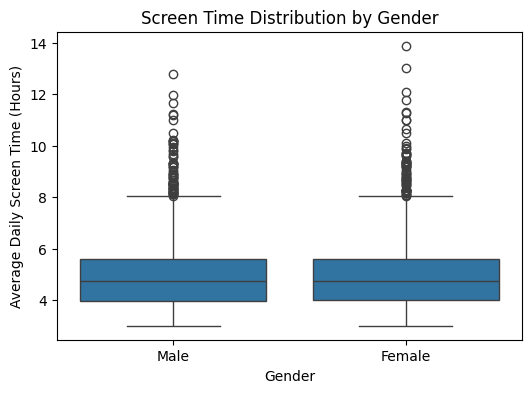

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Gender",y="Avg_Daily_Screen_Time_hr")
plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

Urban vs Rural Screen Time

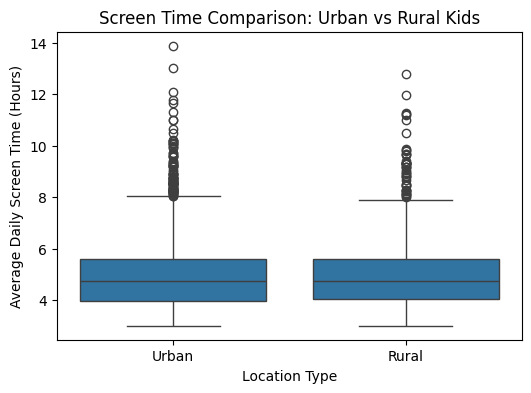

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Urban_or_Rural",y="Avg_Daily_Screen_Time_hr")
plt.title("Screen Time Comparison: Urban vs Rural Kids")
plt.xlabel("Location Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

Screen Time Distribution by Device (Boxplot)

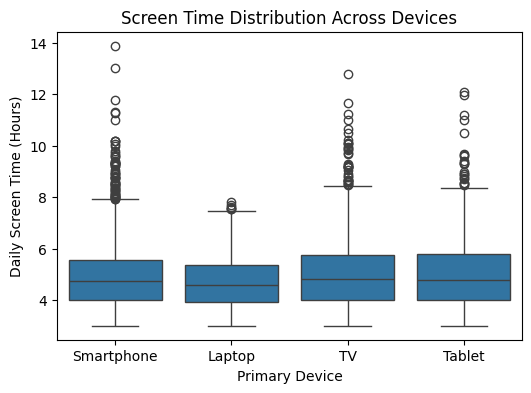

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x="Primary_Device",y="Avg_Daily_Screen_Time_hr")
plt.title("Screen Time Distribution Across Devices")
plt.xlabel("Primary Device")
plt.ylabel("Daily Screen Time (Hours)")
plt.show()

TV users show the highest screen time distribution, followed by tablet users. Smartphone and laptop users show comparatively lower daily screen time.

% Exceeding Recommended Limit by Device

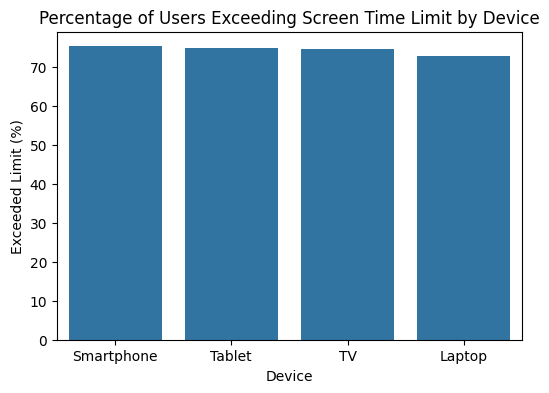

In [24]:
df["Exceeded_Limit"] = df["Avg_Daily_Screen_Time_hr"] > 4
device_risk = (
    df.groupby("Primary_Device")["Exceeded_Limit"]
    .mean()
    .reset_index()
)
device_risk["Exceeded_%"] = device_risk["Exceeded_Limit"] * 100
device_risk = device_risk.sort_values(by="Exceeded_%", ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(
    data=device_risk,
    x="Primary_Device",
    y="Exceeded_%"
)
plt.title("Percentage of Users Exceeding Screen Time Limit by Device")
plt.xlabel("Device")
plt.ylabel("Exceeded Limit (%)")
plt.show()

Smartphones show the highest percentage of users exceeding the recommended screen time limit.This indicates that smartphone-based activities may contribute more to excessive usage.

Usage Balance by Age Band

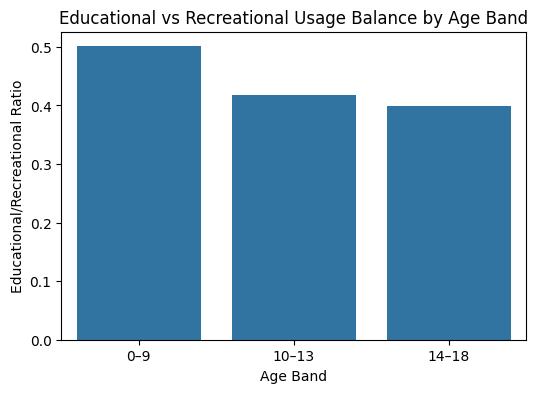

In [25]:
usage_ratio = df.groupby("Age_Band")["Educational_to_Recreational_Ratio"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(
    data=usage_ratio,
    x="Age_Band",
    y="Educational_to_Recreational_Ratio"
)
plt.title("Educational vs Recreational Usage Balance by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Educational/Recreational Ratio")
plt.show()

Younger children (6–9) show a higher educational-to-recreational usage ratio, while older age groups gradually shift toward more recreational screen usage.

Screen Time vs Health Impact

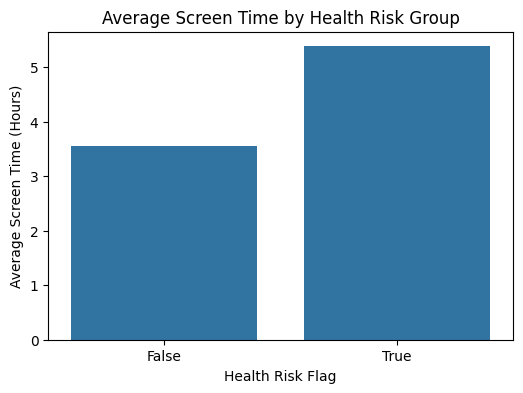

In [26]:
df["Health_Risk_Flag"] = df["Avg_Daily_Screen_Time_hr"] > 4
health = df.groupby("Health_Risk_Flag")["Avg_Daily_Screen_Time_hr"].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(
    data=health,
    x="Health_Risk_Flag",
    y="Avg_Daily_Screen_Time_hr"
)
plt.title("Average Screen Time by Health Risk Group")
plt.xlabel("Health Risk Flag")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

Children classified in the high-risk group (screen time greater than 4 hours) show significantly higher average daily screen time compared to the low-risk group. This indicates that prolonged screen exposure may be associated with potential health concerns.

3. Multivariate Analysis

Average Screen Time by Location and Device

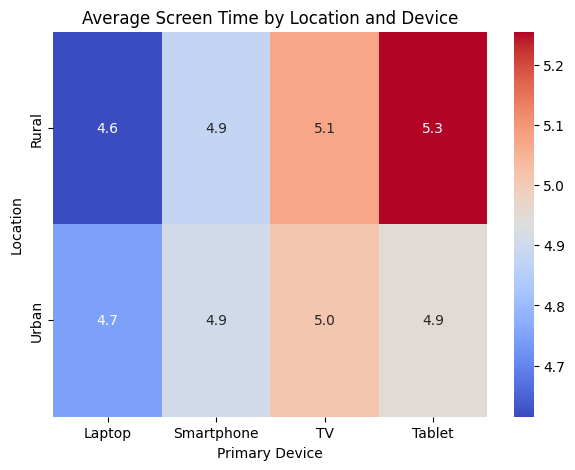

In [27]:
pivot_location = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Urban_or_Rural",
    columns="Primary_Device",
    aggfunc="mean"
)
plt.figure(figsize=(7,5))
sns.heatmap(
    pivot_location,
    annot=True,
    cmap="coolwarm",
    fmt=".1f"
)
plt.title("Average Screen Time by Location and Device")
plt.xlabel("Primary Device")
plt.ylabel("Location")
plt.show()

Average Screen Time by Age band and Device

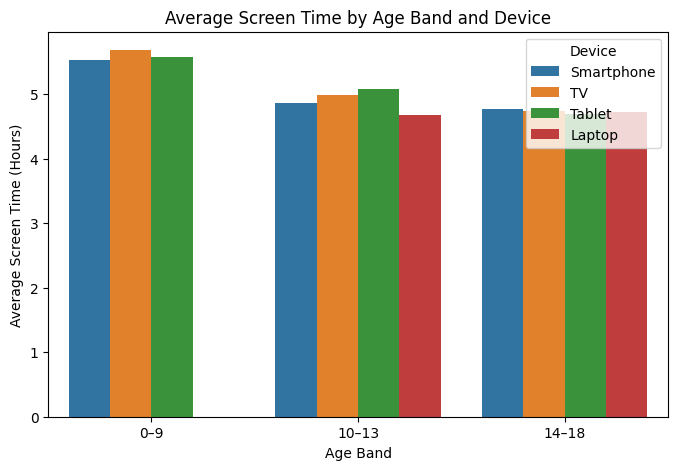

In [28]:
age_device = df.groupby(
    ["Age_Band", "Primary_Device"]
)["Avg_Daily_Screen_Time_hr"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_device,
    x="Age_Band",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)
plt.title("Average Screen Time by Age Band and Device")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.legend(title="Device")
plt.show()

4. Cohort Analysis

Age Band vs Device (Heatmap)

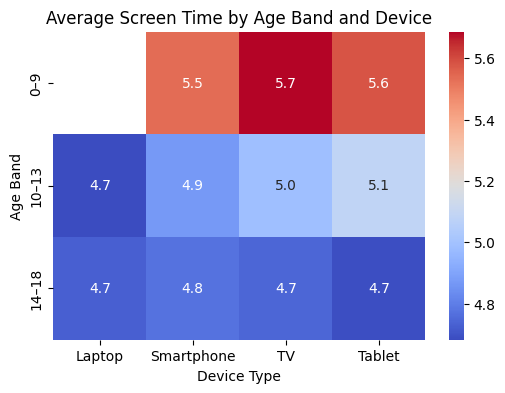

In [29]:
pivot_table = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)
plt.figure(figsize=(6,4))
sns.heatmap(
    pivot_table,
    annot=True,
    cmap="coolwarm",
    fmt=".1f"
)
plt.title("Average Screen Time by Age Band and Device")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

Older age groups using TVs or tablets show higher screen time compared to younger groups. This suggests that device usage patterns change as children grow older.

Device × Exceeded Limit % Table

In [30]:
df["Exceeded_Limit"] = df["Avg_Daily_Screen_Time_hr"] > 4
device_limit = (
    df.groupby("Primary_Device")["Exceeded_Limit"]
    .mean()
    .reset_index()
)
device_limit["Exceeded_%"] = device_limit["Exceeded_Limit"] * 100
device_limit

,Primary_Device,Exceeded_Limit,Exceeded_%
0,Laptop,0.726496,72.649573
1,Smartphone,0.752098,75.209813
2,TV,0.746684,74.668351
3,Tablet,0.747368,74.736842


Around 72–75% of users across all devices exceed the recommended screen time limit, with smartphone users showing the highest proportion.

Identify Top 3 High-Risk Cohorts

In [31]:
cohort = df.groupby(["Age_Band", "Primary_Device", "Urban_or_Rural"])["Avg_Daily_Screen_Time_hr"].mean().reset_index()
cohort_sorted = cohort.sort_values(
    by="Avg_Daily_Screen_Time_hr",
    ascending=False
)

cohort_sorted.head(3)

,Age_Band,Primary_Device,Urban_or_Rural,Avg_Daily_Screen_Time_hr
2,0–9,TV,Rural,5.885368
4,0–9,Tablet,Rural,5.842571
1,0–9,Smartphone,Urban,5.618988


3 Cohort-Level Insights :-

Children aged 6–9 using TV in rural areas show the highest average screen time (about 5.9 hours per day), making this the highest-risk cohort.

Rural children aged 6–9 using tablets also show very high screen exposure, indicating that younger children in rural areas may spend extended time on large-screen devices.

Among urban cohorts, 6–9-year-olds using smartphones demonstrate high screen time, suggesting that mobile devices also contribute significantly to screen exposure among younger users

Policy-Relevant Statement :-

Parents and educators should monitor screen usage among younger children, particularly those aged 6–9, as this group shows unexpectedly high screen exposure across multiple devices.

Limitation :-

The dataset does not capture contextual factors such as parental supervision, type of content consumed, or purpose of screen use, which may influence screen time patterns.

Pivot Table


In [32]:
pivot_table = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

pivot_table

Primary_Device,Laptop,Smartphone,TV,Tablet
Age_Band,,,,
0–9,NaN,5.535108,5.686216,5.580515
10–13,4.682238,4.866842,4.985483,5.084922
14–18,4.728489,4.771940,4.741985,4.687110


In [33]:
df["Health_Risk_Flag"] = df["Avg_Daily_Screen_Time_hr"] > 4
health_age = df.groupby(
    ["Age_Band", "Health_Risk_Flag"]
).size().reset_index(name="Count")

health_age

,Age_Band,Health_Risk_Flag,Count
0,0–9,False,197
1,0–9,True,700
2,10–13,False,608
3,10–13,True,1781
4,14–18,False,844
5,14–18,True,2364


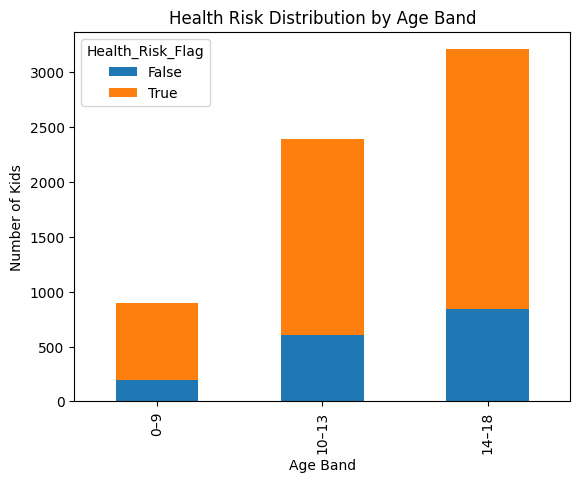

In [34]:
pivot_health = health_age.pivot(
    index="Age_Band",
    columns="Health_Risk_Flag",
    values="Count"
)

pivot_health.plot(kind="bar", stacked=True)

plt.title("Health Risk Distribution by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Kids")

plt.show()

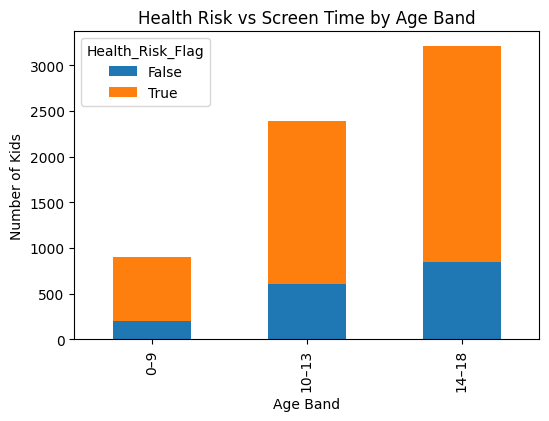

In [35]:
pivot_health = health_age.pivot(
    index="Age_Band",
    columns="Health_Risk_Flag",
    values="Count"
)
pivot_health.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)
plt.title("Health Risk vs Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Kids")
plt.show()

The distribution of high screen-time risk varies across age groups. Certain age bands show a larger proportion of children exceeding the recommended screen time threshold, indicating potential areas for monitoring and intervention.

In [36]:
df.to_csv("Indian_Kids_Screen_Time1_cleaned.csv", index=False)